# install

In [1]:
# Cài đặt hoặc nâng cấp vnstock
!pip install -U vnstock pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.8/275.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.2 MB/s eta 0:00:00


In [2]:
from vnstock import Quote
quote = Quote(symbol='ACB', source='KBS')


📋 Connecting Google Drive account
to save project settings.

Mounted at /content/drive


# Cell 1: Setup + load dữ liệu (2024-01-01 → 2026-07-31)

In [3]:
# Cell 1: Setup + load dữ liệu (2024-01-01 → 2026-07-31)
from vnstock import Quote
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from pykalman import KalmanFilter
import matplotlib.pyplot as plt
from itertools import product

SYMBOLS = ["CTG", "STB"]
START, END = "2024-01-01", "2026-07-31"
IS_CUTOFF = "2025-12-31"

raw = {}
for sym in SYMBOLS:
    df = Quote(symbol=sym, source="KBS").history(start=START, end=END, interval="d")
    raw[sym] = df.set_index("time")[["close"]].sort_index()

price_df = pd.DataFrame({sym: d["close"] for sym, d in raw.items()}).dropna()
price_is = price_df[price_df.index <= IS_CUTOFF]
price_oos = price_df[price_df.index > IS_CUTOFF]

print(f"Full:  {price_df.index.min().date()} → {price_df.index.max().date()}  ({len(price_df)} obs)")
print(f"IS:    {price_is.index.min().date()} → {price_is.index.max().date()}  ({len(price_is)} obs)")
print(f"OOS:   {price_oos.index.min().date()} → {price_oos.index.max().date()}  ({len(price_oos)} obs)")

Full:  2024-01-02 → 2026-07-31  (641 obs)
IS:    2024-01-02 → 2025-12-30  (498 obs)
OOS:   2025-12-31 → 2026-07-31  (143 obs)


# Cell 2: Helper functions — fit static/dynamic hedge ratio (tái sử dụng cho walk-forward)


In [4]:
# Cell 2: Helper functions — fit static/dynamic hedge ratio (tái sử dụng cho walk-forward)
DELTA = 1e-4  # tốc độ "trôi" của beta trong Kalman filter

def fit_static(y: pd.Series, x: pd.Series) -> tuple[float, float]:
    """OLS: y = alpha + beta * x + spread. Trả về (alpha, beta)."""
    x_const = sm.add_constant(x)
    result = sm.OLS(y, x_const).fit()
    return result.params.iloc[0], result.params.iloc[1]

def fit_kalman(y: pd.Series, x: pd.Series,
               init_state_mean: np.ndarray = None,
               init_state_cov: np.ndarray = None,
               delta: float = DELTA):
    """Fit/continue Kalman filter cho dynamic hedge ratio. Trả về (state_means, state_covs, kf)."""
    obs_mat = np.vstack([x.values, np.ones(len(x))]).T[:, np.newaxis, :]
    trans_cov = delta / (1 - delta) * np.eye(2)

    kf = KalmanFilter(
        n_dim_obs=1, n_dim_state=2,
        transition_matrices=np.eye(2),
        observation_matrices=obs_mat,
        observation_covariance=1.0,
        transition_covariance=trans_cov,
        initial_state_mean=init_state_mean if init_state_mean is not None else [0, 0],
        initial_state_covariance=init_state_cov if init_state_cov is not None else np.ones((2, 2)),
    )
    state_means, state_covs = kf.filter(y.values)
    return state_means, state_covs, kf

def spread_static(y, x, alpha, beta) -> pd.Series:
    return y - (alpha + beta * x)

def spread_dynamic(y, x, state_means) -> pd.Series:
    beta_t = pd.Series(state_means[:, 0], index=y.index)
    alpha_t = pd.Series(state_means[:, 1], index=y.index)
    return y - (alpha_t + beta_t * x), beta_t

def sharpe_ratio(returns: pd.Series, periods_per_year: int = 252) -> float:
    if len(returns) == 0 or returns.std() == 0:
        return np.nan
    return returns.mean() / returns.std() * np.sqrt(periods_per_year)

# Cell 3: Fit trên in-sample, tạo spread IS + OOS (giống Ngày 12, gói lại gọn hơn)

In [5]:
# Cell 3: Fit trên in-sample, tạo spread IS + OOS (giống Ngày 12, gói lại gọn hơn)
y_is, x_is = price_is["CTG"], price_is["STB"]
y_oos, x_oos = price_oos["CTG"], price_oos["STB"]

# --- Static ---
alpha_s, beta_s = fit_static(y_is, x_is)
spread_static_is = spread_static(y_is, x_is, alpha_s, beta_s)
spread_static_oos = spread_static(y_oos, x_oos, alpha_s, beta_s)

# --- Dynamic (Kalman) ---
state_means_is, state_covs_is, _ = fit_kalman(y_is, x_is)
spread_dynamic_is, beta_dyn_is = spread_dynamic(y_is, x_is, state_means_is)

state_means_oos, _, _ = fit_kalman(
    y_oos, x_oos,
    init_state_mean=state_means_is[-1], init_state_cov=state_covs_is[-1]
)
spread_dynamic_oos, beta_dyn_oos = spread_dynamic(y_oos, x_oos, state_means_oos)

print(f"Static β (IS):  {beta_s:.4f}")
print(f"Dynamic β cuối IS: {beta_dyn_is.iloc[-1]:.4f}, cuối OOS: {beta_dyn_oos.iloc[-1]:.4f}")

Static β (IS):  0.4596
Dynamic β cuối IS: 0.5799, cuối OOS: 0.4118


# Cell 4: backtest_with_cost() — thêm transaction cost + slippage vào backtest cũ

In [6]:
# Cell 4: backtest_with_cost() — thêm transaction cost + slippage vào backtest cũ
# Giả định:
# - Transaction cost: 0.15% mỗi lượt round-trip (mua+bán) khi ĐỔI vị thế (position.diff() != 0)
# - Slippage: 0.08% mỗi lần đổi vị thế (ước lượng do bid-ask spread, trong khoảng 0.05-0.1% theo yêu cầu)
# - Cost tính trên "notional" ước lượng = giá y_t + |beta_t| * giá x_t (tổng giá trị 2 chân của cặp)
#   → đây là xấp xỉ hợp lý vì spread đang ở đơn vị giá (price units), không phải % return
TRANSACTION_COST = 0.0015
SLIPPAGE = 0.0008
TOTAL_COST_RATE = TRANSACTION_COST + SLIPPAGE

def backtest_with_cost(spread: pd.Series, notional: pd.Series,
                        entry_z: float = 1.5, exit_z: float = 0.5,
                        cost_rate: float = TOTAL_COST_RATE,
                        window: int = 20) -> pd.DataFrame:
    """
    Trả về DataFrame gồm: position, gross_ret (chưa trừ phí), cost, net_ret (đã trừ phí).
    Logic entry/exit giữ nguyên như Ngày 11-12, chỉ thêm cost khi position thay đổi.
    """
    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
    z = z.dropna()

    position = pd.Series(0, index=z.index)
    pos = 0
    for t in z.index:
        if pos == 0:
            if z[t] < -entry_z:
                pos = 1
            elif z[t] > entry_z:
                pos = -1
        else:
            if abs(z[t]) < exit_z:
                pos = 0
        position[t] = pos

    spread_ret = spread.diff().reindex(position.index)
    gross_ret = position.shift(1) * spread_ret

    # Cost phát sinh mỗi khi vị thế thay đổi (entry HOẶC exit đều tính, vì đều cần trade 2 chân)
    position_change = position.diff().fillna(position.iloc[0]).abs().clip(upper=1)  # 0/1 flag đổi vị thế
    notional_aligned = notional.reindex(position.index)
    cost = position_change * cost_rate * notional_aligned

    net_ret = (gross_ret - cost).dropna()

    return pd.DataFrame({
        "position": position,
        "gross_ret": gross_ret,
        "cost": cost,
        "net_ret": net_ret,
    }).dropna()

# Notional ước lượng cho static & dynamic
notional_is_static = y_is + abs(beta_s) * x_is
notional_oos_static = y_oos + abs(beta_s) * x_oos
notional_is_dynamic = y_is + beta_dyn_is.abs() * x_is
notional_oos_dynamic = y_oos + beta_dyn_oos.abs() * x_oos

# Cell 5: Chạy backtest CÓ phí — Static vs Dynamic, IS vs OOS, so Sharpe trước/sau phí

In [7]:
# Cell 5: Chạy backtest CÓ phí — Static vs Dynamic, IS vs OOS, so Sharpe trước/sau phí
# Nối 20 obs cuối IS vào OOS để rolling window không bị NaN đầu kỳ (giống Ngày 12)
spread_static_full = pd.concat([spread_static_is.tail(20), spread_static_oos])
spread_dynamic_full = pd.concat([spread_dynamic_is.tail(20), spread_dynamic_oos])
notional_static_full = pd.concat([notional_is_static.tail(20), notional_oos_static])
notional_dynamic_full = pd.concat([notional_is_dynamic.tail(20), notional_oos_dynamic])

results = {}
for name, spread, notional, oos_index in [
    ("Static-IS", spread_static_is, notional_is_static, price_is.index),
    ("Dynamic-IS", spread_dynamic_is, notional_is_dynamic, price_is.index),
    ("Static-OOS", spread_static_full, notional_static_full, price_oos.index),
    ("Dynamic-OOS", spread_dynamic_full, notional_dynamic_full, price_oos.index),
]:
    bt = backtest_with_cost(spread, notional)
    bt = bt.loc[bt.index.isin(oos_index)]  # chỉ giữ phần đúng kỳ (loại phần warm-up nối thêm)
    results[name] = bt

summary = pd.DataFrame({
    name: {
        "Sharpe gross (trước phí)": sharpe_ratio(bt["gross_ret"]),
        "Sharpe net (sau phí)": sharpe_ratio(bt["net_ret"]),
        "Total cost": bt["cost"].sum(),
        "N trades (đổi vị thế)": (bt["position"].diff().fillna(0) != 0).sum(),
        "Cumulative P&L gross": bt["gross_ret"].sum(),
        "Cumulative P&L net": bt["net_ret"].sum(),
    } for name, bt in results.items()
}).T.round(3)

print(summary)

print(f"\n{'='*70}")
print("PHÍ 'ĂN MÒN' SHARPE NHƯ THẾ NÀO?")
print(f"{'='*70}")
for name in ["Static-IS", "Dynamic-IS", "Static-OOS", "Dynamic-OOS"]:
    row = summary.loc[name]
    drop_pct = (row["Sharpe gross (trước phí)"] - row["Sharpe net (sau phí)"]) / abs(row["Sharpe gross (trước phí)"]) * 100 if row["Sharpe gross (trước phí)"] != 0 else np.nan
    print(f"{name:<14} Sharpe {row['Sharpe gross (trước phí)']:.2f} → {row['Sharpe net (sau phí)']:.2f}  "
          f"(giảm {drop_pct:.0f}%, {int(row['N trades (đổi vị thế)'])} lần đổi vị thế)")

print("\n📌 Chiến lược giao dịch nhiều lần hơn (thường là Static do spread noisy hơn) sẽ bị")
print("   phí bào mòn Sharpe mạnh hơn tương đối so với chiến lược ít giao dịch.")

             Sharpe gross (trước phí)  Sharpe net (sau phí)  Total cost  \
Static-IS                       0.771                 0.071       6.352   
Dynamic-IS                      3.307                 1.678      11.169   
Static-OOS                      2.423                 1.832       3.452   
Dynamic-OOS                     4.095                 2.801       4.252   

             N trades (đổi vị thế)  Cumulative P&L gross  Cumulative P&L net  
Static-IS                     61.0                 6.984               0.632  
Dynamic-IS                    92.0                22.548              11.378  
Static-OOS                    23.0                13.309               9.857  
Dynamic-OOS                   27.0                12.484               8.232  

PHÍ 'ĂN MÒN' SHARPE NHƯ THẾ NÀO?
Static-IS      Sharpe 0.77 → 0.07  (giảm 91%, 61 lần đổi vị thế)
Dynamic-IS     Sharpe 3.31 → 1.68  (giảm 49%, 92 lần đổi vị thế)
Static-OOS     Sharpe 2.42 → 1.83  (giảm 24%, 23 lần đổi vị thế)


Chiến lược dùng beta tĩnh bị ăn mòn mạnh hơn do phí, mặc dù số lần đổi vị thế ít hơn

=> Điều này chứng tỏ Kalman nắm cơ hội tốt hơn, trade nhiều hơn và mang lại đúng hiệu quả

Bằng chứng: Đem lại hiệu quả tốt hơn dù trade nhiều hơn

# Cell 6: Purged K-Fold CV — tự code, không dùng thư viện

In [8]:
# Cell 6: Purged K-Fold CV — tự code, không dùng thư viện
def purged_kfold_splits(n_samples: int, n_splits: int = 5, embargo: int = 5):
    """
    Time-ordered K-Fold với purging/embargo:
    - Chia dữ liệu thành n_splits khối liên tục theo thời gian.
    - Mỗi khối lần lượt làm test set, phần còn lại làm train set.
    - Purge: loại bỏ `embargo` ngày ở HAI ĐẦU test set khỏi train set,
      vì rolling(20) z-score dùng thông tin xuyên biên giới train/test → rò rỉ nếu không purge.
    Yield: (train_idx, test_idx) — mảng vị trí (positional index), không phải label.
    """
    indices = np.arange(n_samples)
    fold_sizes = np.full(n_splits, n_samples // n_splits)
    fold_sizes[: n_samples % n_splits] += 1

    current = 0
    for fold_size in fold_sizes:
        test_start, test_end = current, current + fold_size
        test_idx = indices[test_start:test_end]

        embargo_start = max(0, test_start - embargo)
        embargo_end = min(n_samples, test_end + embargo)

        train_idx = np.concatenate([
            indices[:embargo_start],
            indices[embargo_end:]
        ])
        yield train_idx, test_idx
        current = test_end

# Sanity check: purged CV không leak — train và test (kể cả embargo) không giao nhau
n_test = len(spread_static_is)
for i, (train_idx, test_idx) in enumerate(purged_kfold_splits(n_test, n_splits=5, embargo=5)):
    overlap = set(train_idx) & set(test_idx)
    print(f"Fold {i+1}: train={len(train_idx)}, test={len(test_idx)}, overlap={len(overlap)} "
          f"{'✅' if len(overlap)==0 else '❌ LEAK'}")

Fold 1: train=393, test=100, overlap=0 ✅
Fold 2: train=388, test=100, overlap=0 ✅
Fold 3: train=388, test=100, overlap=0 ✅
Fold 4: train=389, test=99, overlap=0 ✅
Fold 5: train=394, test=99, overlap=0 ✅


# Cell 7: Grid search entry_z / exit_z bằng Purged K-Fold CV (thay vì chọn tay)

In [9]:
# Cell 7: Grid search entry_z / exit_z bằng Purged K-Fold CV (thay vì chọn tay)
ENTRY_GRID = [1.0, 1.5, 2.0, 2.5]
EXIT_GRID = [0.25, 0.5, 0.75]
N_SPLITS = 5
EMBARGO = 5

# Dùng static spread trên toàn bộ in-sample để chọn tham số (áp dụng tương tự được cho dynamic)
spread_cv = spread_static_is.reset_index(drop=True)
notional_cv = notional_is_static.reset_index(drop=True)
spread_cv.index = spread_static_is.index  # giữ lại datetime index để backtest_with_cost hoạt động đúng
notional_cv.index = spread_static_is.index

cv_results = []
for entry_z, exit_z in product(ENTRY_GRID, EXIT_GRID):
    if exit_z >= entry_z:
        continue  # exit phải nhỏ hơn entry, tránh cấu hình vô nghĩa

    fold_sharpes = []
    for train_idx, test_idx in purged_kfold_splits(len(spread_static_is), N_SPLITS, EMBARGO):
        test_dates = spread_static_is.index[test_idx]
        if len(test_dates) < 25:  # quá ngắn, rolling(20) không đủ data để có tín hiệu
            continue

        bt = backtest_with_cost(
            spread_static_is.loc[test_dates[0]:test_dates[-1]],
            notional_is_static.loc[test_dates[0]:test_dates[-1]],
            entry_z=entry_z, exit_z=exit_z
        )
        if len(bt) > 5:
            fold_sharpes.append(sharpe_ratio(bt["net_ret"]))

    if fold_sharpes:
        cv_results.append({
            "entry_z": entry_z, "exit_z": exit_z,
            "mean_sharpe_cv": np.nanmean(fold_sharpes),
            "std_sharpe_cv": np.nanstd(fold_sharpes),
            "n_folds_valid": len(fold_sharpes),
        })

cv_df = pd.DataFrame(cv_results).sort_values("mean_sharpe_cv", ascending=False)
print(cv_df.to_string(index=False))

best_params = cv_df.iloc[0]
print(f"\n🏆 Tham số tốt nhất (theo Purged CV): entry_z={best_params['entry_z']}, exit_z={best_params['exit_z']}")
print(f"   Mean Sharpe (CV, net phí): {best_params['mean_sharpe_cv']:.3f} ± {best_params['std_sharpe_cv']:.3f}")
print("\n⚠️  So sánh với entry_z=1.5, exit_z=0.5 đã dùng 'chọn tay' ở Ngày 11-12 —")
print("   nếu 2 bộ tham số khác nhau nhiều, cho thấy việc chọn tay có rủi ro data snooping.")

 entry_z  exit_z  mean_sharpe_cv  std_sharpe_cv  n_folds_valid
     1.0    0.25        0.299205       1.046247              5
     1.5    0.50        0.195946       1.603589              5
     1.5    0.75       -0.019175       1.611975              5
     2.0    0.50       -0.164570       1.073362              5
     1.5    0.25       -0.257384       1.479572              5
     2.0    0.25       -0.281302       1.283459              5
     2.0    0.75       -0.357209       1.266934              5
     1.0    0.50       -0.473724       1.644245              5
     2.5    0.50       -0.489569       0.931958              5
     2.5    0.75       -0.637444       1.112603              5
     1.0    0.75       -0.674884       1.858736              5
     2.5    0.25       -0.961111       1.516030              5

🏆 Tham số tốt nhất (theo Purged CV): entry_z=1.0, exit_z=0.25
   Mean Sharpe (CV, net phí): 0.299 ± 1.046

⚠️  So sánh với entry_z=1.5, exit_z=0.5 đã dùng 'chọn tay' ở Ngày 11-12 —

Khi phát triển thành project/product, chúng ta sẽ cần dùng công thức, để mô hình tự chọn điểm vào ra phù hợp dựa trên thống kê và theo giai đoạn, chứ không dùng 1 số cố định

# Cell 8: Walk-forward rolling re-fit (refit mỗi 60 ngày, forecast 20 ngày tiếp theo)

In [10]:
# Cell 8: Walk-forward rolling re-fit (refit mỗi 60 ngày, forecast 20 ngày tiếp theo)
TRAIN_WINDOW = 60   # số ngày dùng để refit static/dynamic mỗi lần
TEST_WINDOW = 20    # số ngày forecast/backtest tiếp theo
STEP = TEST_WINDOW  # trượt cửa sổ đúng bằng test window (không chồng lấn)

def run_walk_forward(price_data: pd.DataFrame,
                      train_window: int = TRAIN_WINDOW,
                      test_window: int = TEST_WINDOW,
                      entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """
    Với mỗi bước: dùng [t-train_window, t) để fit static & dynamic,
    backtest trên [t, t+test_window) — ghép nối tất cả các đoạn test lại để đánh giá độ ổn định.
    """
    records = []
    n = len(price_data)
    kalman_state_mean, kalman_state_cov = None, None

    for start in range(train_window, n - test_window, step := STEP):
        train = price_data.iloc[start - train_window: start]
        test = price_data.iloc[start: start + test_window]

        y_tr, x_tr = train["CTG"], train["STB"]
        y_te, x_te = test["CTG"], test["STB"]

        # --- Static: refit mới hoàn toàn mỗi window ---
        a_s, b_s = fit_static(y_tr, x_tr)
        sp_static_train = spread_static(y_tr, x_tr, a_s, b_s)
        sp_static_test = spread_static(y_te, x_te, a_s, b_s)
        sp_static_full = pd.concat([sp_static_train.tail(20), sp_static_test])
        notional_static_te = y_te + abs(b_s) * x_te
        notional_static_full = pd.concat([(y_tr + abs(b_s) * x_tr).tail(20), notional_static_te])

        bt_static = backtest_with_cost(sp_static_full, notional_static_full, entry_z, exit_z)
        bt_static = bt_static.loc[bt_static.index.isin(test.index)]

        # --- Dynamic: continue Kalman từ state trước đó (nếu có), refit trên train window ---
        sm_train, sc_train, _ = fit_kalman(y_tr, x_tr,
                                            init_state_mean=kalman_state_mean,
                                            init_state_cov=kalman_state_cov)
        sp_dyn_train, beta_tr = spread_dynamic(y_tr, x_tr, sm_train)
        kalman_state_mean, kalman_state_cov = sm_train[-1], sc_train[-1]

        sm_test, sc_test, _ = fit_kalman(y_te, x_te,
                                          init_state_mean=kalman_state_mean,
                                          init_state_cov=kalman_state_cov)
        sp_dyn_test, beta_te = spread_dynamic(y_te, x_te, sm_test)
        kalman_state_mean, kalman_state_cov = sm_test[-1], sc_test[-1]  # cập nhật cho window sau

        sp_dyn_full = pd.concat([sp_dyn_train.tail(20), sp_dyn_test])
        notional_dyn_te = y_te + beta_te.abs() * x_te
        notional_dyn_full = pd.concat([(y_tr + beta_tr.abs() * x_tr).tail(20), notional_dyn_te])

        bt_dynamic = backtest_with_cost(sp_dyn_full, notional_dyn_full, entry_z, exit_z)
        bt_dynamic = bt_dynamic.loc[bt_dynamic.index.isin(test.index)]

        records.append({
            "window_start": test.index[0], "window_end": test.index[-1],
            "sharpe_static": sharpe_ratio(bt_static["net_ret"]) if len(bt_static) > 3 else np.nan,
            "sharpe_dynamic": sharpe_ratio(bt_dynamic["net_ret"]) if len(bt_dynamic) > 3 else np.nan,
            "pnl_static": bt_static["net_ret"].sum(),
            "pnl_dynamic": bt_dynamic["net_ret"].sum(),
        })

    return pd.DataFrame(records)

wf_results = run_walk_forward(price_df, entry_z=best_params["entry_z"], exit_z=best_params["exit_z"])
print(wf_results.round(3))

          window_start          window_end  sharpe_static  sharpe_dynamic  \
0  2024-04-02 07:00:00 2024-05-03 07:00:00          3.268           1.071   
1  2024-05-06 07:00:00 2024-05-31 07:00:00         -0.253           0.295   
2  2024-06-03 07:00:00 2024-06-28 07:00:00         -3.095           1.227   
3  2024-07-01 07:00:00 2024-07-26 07:00:00          3.928           1.174   
4  2024-07-29 07:00:00 2024-08-23 07:00:00         -3.978          -0.681   
5  2024-08-26 07:00:00 2024-09-24 07:00:00         -0.829          -1.501   
6  2024-09-25 07:00:00 2024-10-22 07:00:00         -6.888           1.498   
7  2024-10-23 07:00:00 2024-11-19 07:00:00          1.404           1.519   
8  2024-11-20 07:00:00 2024-12-17 07:00:00          5.994           0.232   
9  2024-12-18 07:00:00 2025-01-15 07:00:00          2.226           0.140   
10 2025-01-16 07:00:00 2025-02-19 07:00:00         -0.345           0.127   
11 2025-02-20 07:00:00 2025-03-19 07:00:00         -1.604           1.482   

# Cell 9: Đánh giá độ ổn định walk-forward

ĐỘ ỔN ĐỊNH QUA CÁC WALK-FORWARD WINDOW
Số window: 29

Static  — Sharpe mean: -0.062, std: 3.485, % window dương: 48%
Dynamic — Sharpe mean: 1.626, std: 1.653, % window dương: 86%


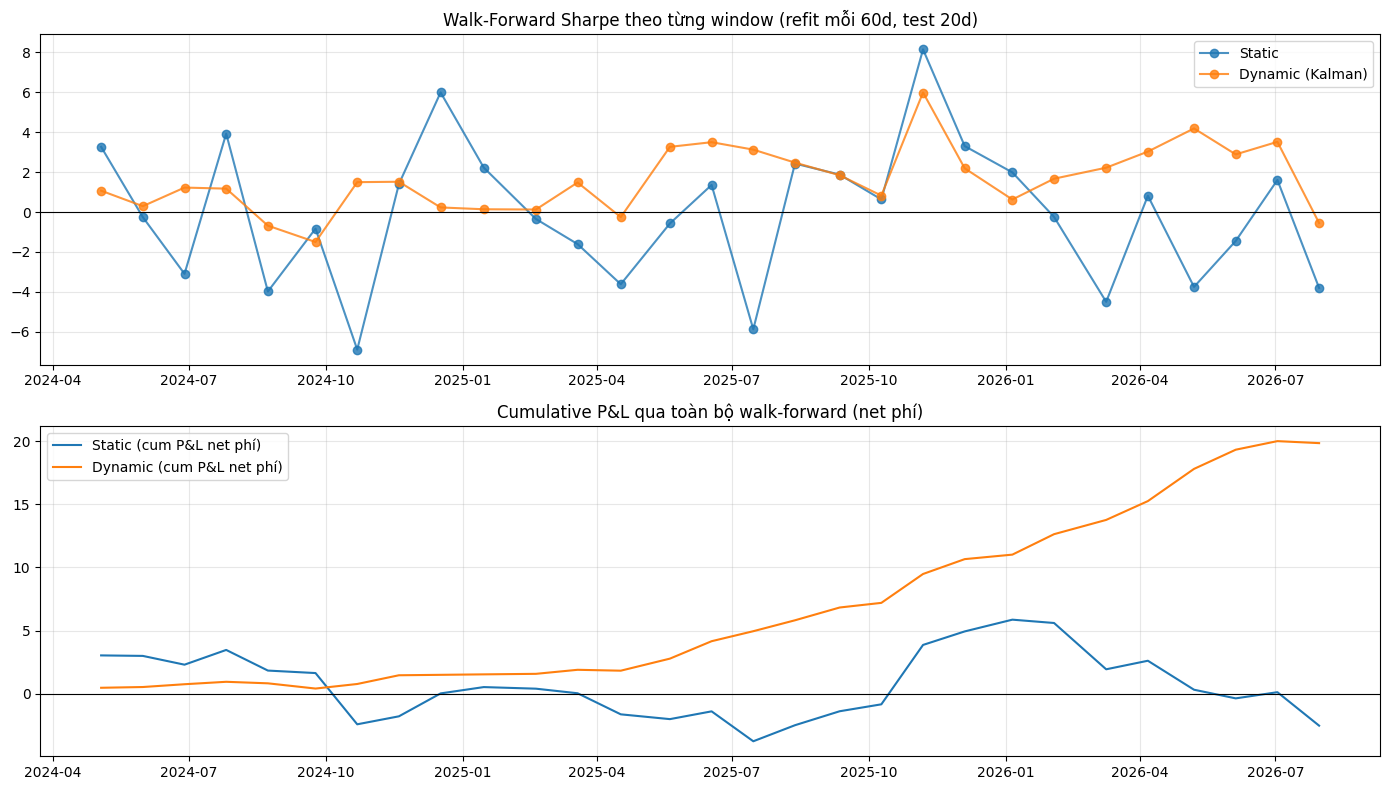


📌 Nếu Sharpe dao động mạnh giữa các window (std cao) hoặc đổi dấu liên tục,
   đó là dấu hiệu chiến lược KHÔNG ổn định qua các regime khác nhau —
   quan trọng hơn nhiều so với 1 con số Sharpe duy nhất trên 1 lần chia IS/OOS.


In [11]:
# Cell 9: Đánh giá độ ổn định walk-forward
print(f"{'='*70}")
print("ĐỘ ỔN ĐỊNH QUA CÁC WALK-FORWARD WINDOW")
print(f"{'='*70}")
print(f"Số window: {len(wf_results)}")
print(f"\nStatic  — Sharpe mean: {wf_results['sharpe_static'].mean():.3f}, "
      f"std: {wf_results['sharpe_static'].std():.3f}, "
      f"% window dương: {(wf_results['pnl_static'] > 0).mean()*100:.0f}%")
print(f"Dynamic — Sharpe mean: {wf_results['sharpe_dynamic'].mean():.3f}, "
      f"std: {wf_results['sharpe_dynamic'].std():.3f}, "
      f"% window dương: {(wf_results['pnl_dynamic'] > 0).mean()*100:.0f}%")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(wf_results["window_end"], wf_results["sharpe_static"], "o-", label="Static", alpha=0.8)
ax1.plot(wf_results["window_end"], wf_results["sharpe_dynamic"], "o-", label="Dynamic (Kalman)", alpha=0.8)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_title(f"Walk-Forward Sharpe theo từng window (refit mỗi {TRAIN_WINDOW}d, test {TEST_WINDOW}d)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(wf_results["window_end"], wf_results["pnl_static"].cumsum(), label="Static (cum P&L net phí)")
ax2.plot(wf_results["window_end"], wf_results["pnl_dynamic"].cumsum(), label="Dynamic (cum P&L net phí)")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Cumulative P&L qua toàn bộ walk-forward (net phí)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Nếu Sharpe dao động mạnh giữa các window (std cao) hoặc đổi dấu liên tục,")
print("   đó là dấu hiệu chiến lược KHÔNG ổn định qua các regime khác nhau —")
print("   quan trọng hơn nhiều so với 1 con số Sharpe duy nhất trên 1 lần chia IS/OOS.")

Beta tĩnh có sharpe liên tục biến động, gần như không thể dự đoán

Lợi nhuận của beta tĩnh cũng biến động liên tục, tuy có giai đoạn có lợi nhuận lớn, nhưng lỗ lại đem lại kết quả lũy kế không tốt

Ngược lại, với chiến lược dùng beta động, Sharpe không đổi dấu thường xuyên chứng minh nó ổn định hơn (tuy vẫn có giai đoạn shapre cũng tăng cao / âm)

Kết quả được thể hiện qua lợi nhuận lũy kế của nó rất ổn định, và không bị âm qua các giai đoạn, tăng lên từ từ chứ không bật mạnh (kể cả sau khi đã trừ hết phí)